In [8]:
import numpy as np
import pandas as pd
import torch.optim as optim
import matplotlib.pyplot as plt

# -----------------------
# 0) Choose features
# -----------------------
features = ["Bjet1_pt", "Bjet1_eta", "Bjet1_mass", "Bjet1_phi", "Bjet2_mass", "Bjet2_pt", "Bjet2_phi", "Bjet2_eta"]

total_df = pd.read_csv('/Users/yuntongzhou/Desktop/Dihiggszztt/output/Mtauzerob_infer_OS.csv')
reweighted_df = pd.read_csv('/Users/yuntongzhou/Desktop/Dihiggszztt/training/session_1_data_new_weights.csv')
w_data_reco_p3 = reweighted_df['weight_reco_p3'].to_numpy()
MC_df = total_df[total_df['group'] != 'Data'].copy()
data_df = reweighted_df[reweighted_df['group'] == 'Data'].copy()

/var/folders/w4/tl7q52611yg4x42kkpb7bm0m0000gn/T/ipykernel_24401/3980558389.py:11: DtypeWarning: Columns (29) have mixed types. Specify dtype option on import or set low_memory=False.
  total_df = pd.read_csv('/Users/yuntongzhou/Desktop/Dihiggszztt/output/Mtauzerob_infer_OS.csv')


In [ ]:
def plot_true_p3(data_df, mc_df, features, bins=50, 
                 data_weight_col=None, mc_weight_col="weight"):
    """
    Plot h_true_p3 = (Data - MC) for each feature.
    Only plot up to the 90th percentile of combined values (Data + MC).
    """

    # Event weights
    w_data = data_df[data_weight_col].values if data_weight_col and data_weight_col in data_df else np.ones(len(data_df))
    w_mc   = mc_df[mc_weight_col].values if mc_weight_col and mc_weight_col in mc_df else np.ones(len(mc_df))

    nfeat = len(features)
    fig, axs = plt.subplots(nfeat, 1, figsize=(8, 3 * nfeat), constrained_layout=True)

    if nfeat == 1:
        axs = [axs]  # make iterable

    for i, feat in enumerate(features):
        data_vals = data_df[feat].values
        mc_vals   = mc_df[feat].values

        # Cut at 90th percentile
        upper = np.percentile(np.concatenate([data_vals, mc_vals]), 90)

        # Apply masks
        data_mask = data_vals <= upper
        mc_mask = mc_vals <= upper

        # Compute histograms
        h_data, bin_edges = np.histogram(
            data_vals[data_mask], bins=bins, range=(0, upper), weights=w_data[data_mask]
        )
        h_mc, _ = np.histogram(
            mc_vals[mc_mask], bins=bin_edges, weights=w_mc[mc_mask]
        )

        # Difference = true p3
        h_true_p3 = h_data - h_mc

        # Plot
        bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
        axs[i].step(bin_centers, h_true_p3, where="mid", label=f"{feat} (Data - MC)")
        axs[i].axhline(0, color="black", linestyle="--", linewidth=1)
        axs[i].set_xlabel(feat)
        axs[i].set_ylabel("h_true_p3")
        axs[i].legend()

    plt.show()

features = ["DiJet_mass", "DiJet_pt"]
total_df = pd.read_csv('/Users/yuntongzhou/Desktop/Dihiggszztt/output/Mtauzerob_infer_OS.csv')
data_df = total_df[total_df['group'] == 'Data'].copy()
mc_df = total_df[total_df['group'] != 'Data'].copy()

plot_true_p3(data_df, mc_df, features, bins=20)


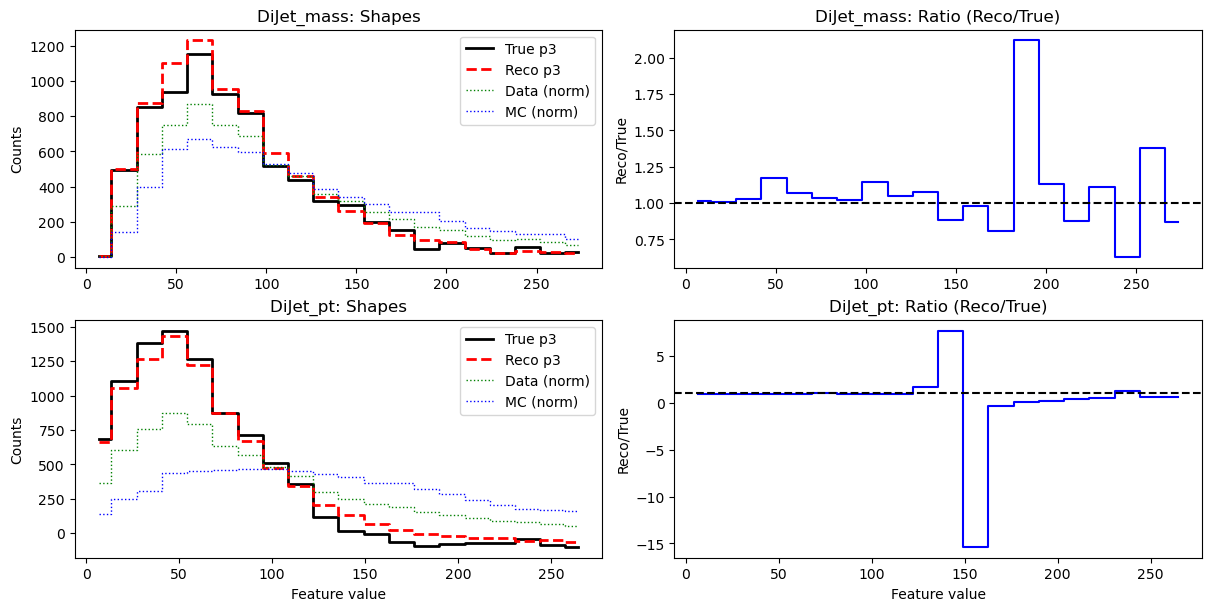

In [9]:
import matplotlib.pyplot as plt
import numpy as np

def plot_feature_comparison_extended(data_df, mc_df, features, w_data_reco_p3,
                                     bins=50, data_weight_col=None, mc_weight_col="weight"):
    """
    Compare True p3, Reco p3, original data, and original MC in 1D histograms
    for each feature, including event weights.

    Only plot the central 90% of events for each feature (5th to 95th percentile).
    """
    # Event weights
    w_data = data_df[data_weight_col].values if data_weight_col and data_weight_col in data_df else np.ones(len(data_df))
    w_mc   = mc_df[mc_weight_col].values if mc_weight_col and mc_weight_col in mc_df else np.ones(len(mc_df))

    # Normalization factor for original data and MC to compare with p3
    target_sum = w_data.sum() - w_mc.sum()
    norm_data = target_sum / (w_data.sum() + 1e-12)
    norm_mc   = target_sum / (w_mc.sum() + 1e-12)

    nfeat = len(features)
    fig, axs = plt.subplots(nfeat, 2, figsize=(12, 3 * nfeat), constrained_layout=True)

    for i, feat in enumerate(features):
        data_vals = data_df[feat].values
        mc_vals   = mc_df[feat].values

        # Compute 90th percentile from both data and MC
        upper = np.percentile(np.concatenate([data_vals, mc_vals]), 90)

        # Mask values below the 90th percentile
        data_mask = data_vals <= upper
        mc_mask = mc_vals <= upper

        # --- True p3 distribution (data - mc)
        h_data, bin_edges = np.histogram(data_vals[data_mask], bins=bins, range=(0, upper), weights=w_data[data_mask], density=False)
        h_mc,   _         = np.histogram(mc_vals[mc_mask], bins=bin_edges, weights=w_mc[mc_mask], density=False)
        h_true_p3 = h_data - h_mc

        # --- Reco p3 distribution (weights on data events)
        h_reco_p3, _ = np.histogram(data_vals[data_mask], bins=bin_edges, weights=w_data_reco_p3[data_mask], density=False)

        # --- Original data normalized
        h_data_norm, _ = np.histogram(data_vals[data_mask], bins=bin_edges, weights=w_data[data_mask]*norm_data, density=False)

        # --- Original MC normalized
        h_mc_norm, _   = np.histogram(mc_vals[mc_mask], bins=bin_edges, weights=w_mc[mc_mask]*norm_mc, density=False)

        centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

        # --- Left panel: shapes
        axs[i,0].step(centers, h_true_p3, where="mid", label="True p3", color="black", lw=2)
        axs[i,0].step(centers, h_reco_p3, where="mid", label="Reco p3", color="red", lw=2, linestyle="--")
        axs[i,0].step(centers, h_data_norm, where="mid", label="Data (norm)", color="green", lw=1, linestyle=":")
        axs[i,0].step(centers, h_mc_norm, where="mid", label="MC (norm)", color="blue", lw=1, linestyle=":")
        axs[i,0].set_ylabel("Counts")
        axs[i,0].set_title(f"{feat}: Shapes")
        axs[i,0].legend()

        # --- Right panel: relative difference (Reco - True) / True
        mask = h_true_p3 != 0
        rel_diff = np.zeros_like(h_true_p3, dtype=float)
        rel_diff[mask] = (h_reco_p3[mask] - h_true_p3[mask]) / h_true_p3[mask]
        # --- Right panel: ratio (Reco / True)
        ratio = np.ones_like(h_true_p3, dtype=float)
        mask = h_true_p3 != 0
        ratio[mask] = h_reco_p3[mask] / h_true_p3[mask]
        axs[i,1].step(centers, ratio, where="mid", color="blue")
        axs[i,1].axhline(1, color="k", linestyle="--")
        axs[i,1].set_ylabel("Reco/True")
        axs[i,1].set_title(f"{feat}: Ratio (Reco/True)")

    axs[-1,0].set_xlabel("Feature value")
    axs[-1,1].set_xlabel("Feature value")
    plt.show()

features = ["DiJet_mass", "DiJet_pt"]
plot_feature_comparison_extended(data_df, mc_df, features, w_data_reco_p3, bins=20, mc_weight_col="weight")

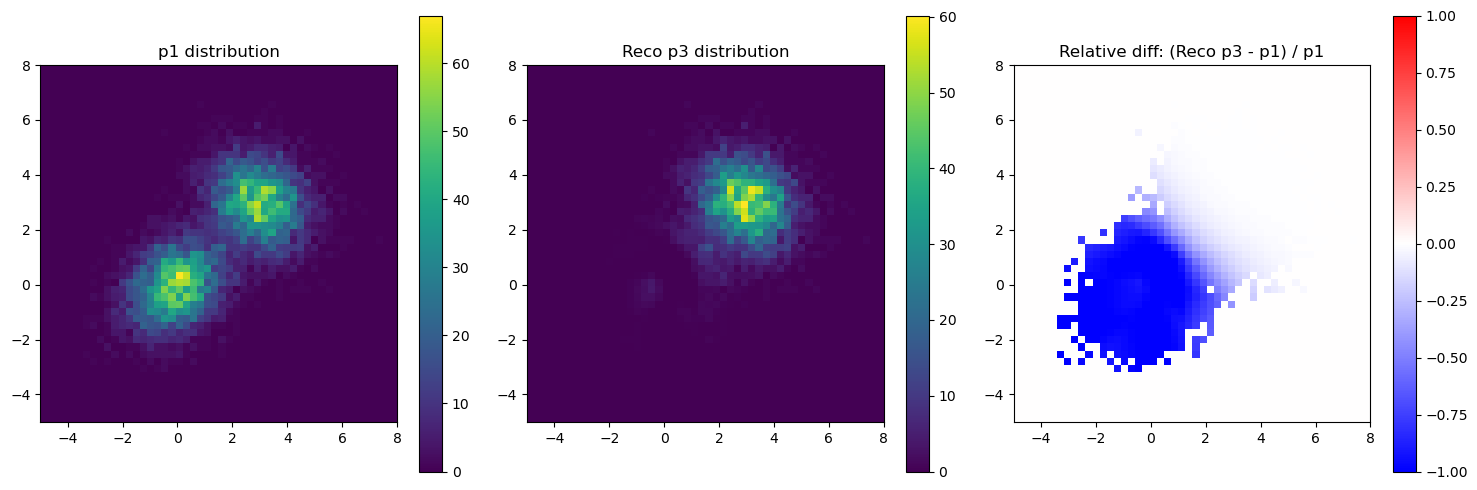

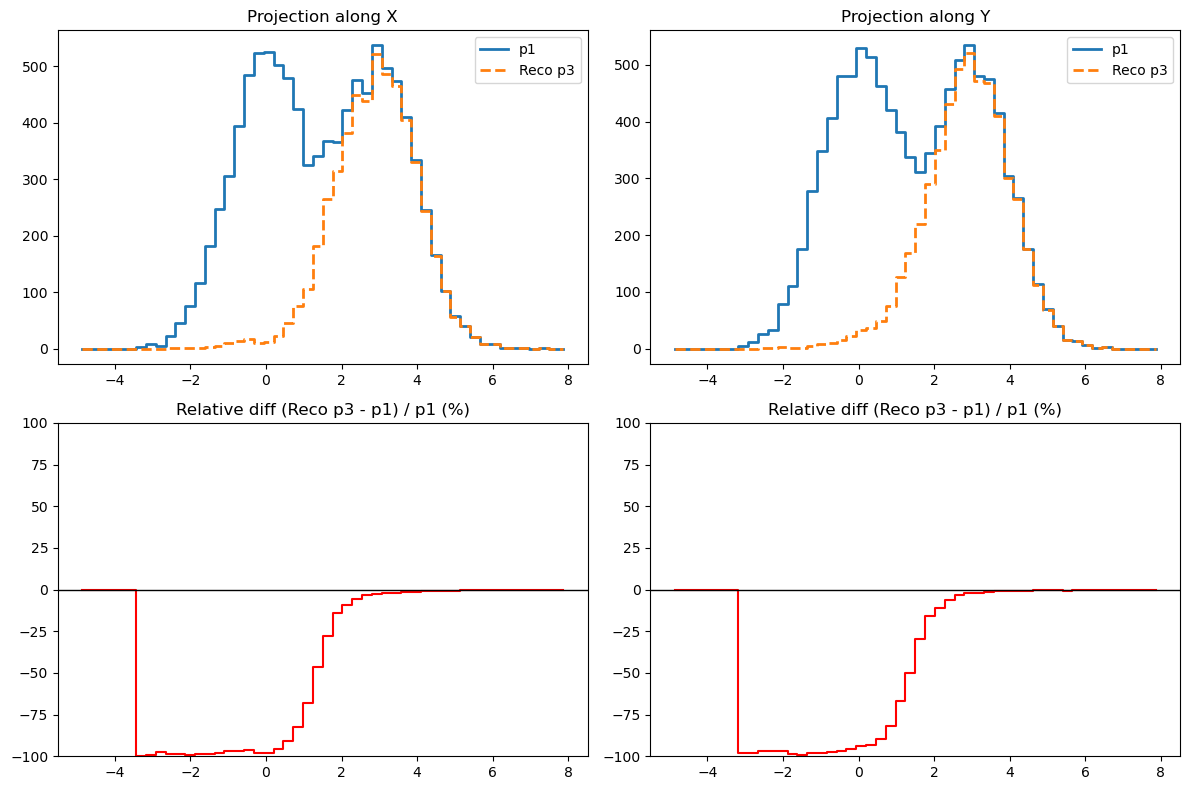

In [12]:
# -----------------------
# 8. Compare shapes: p1 vs Reco p3
# -----------------------
# 2D hist for p1 is H_p1 (already computed)
# Relative difference
mask_nonzero_p1 = H_p1 != 0
rel_diff_p1_vs_p3 = np.zeros_like(H_p1, dtype=float)
rel_diff_p1_vs_p3[mask_nonzero_p1] = (H_p3_reco[mask_nonzero_p1] - H_p1[mask_nonzero_p1]) / H_p1[mask_nonzero_p1]

# Plot 2D comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

im0 = axes[0].imshow(H_p1.T, origin='lower', extent=[-5,8,-5,8])
axes[0].set_title("p1 distribution")
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(H_p3_reco.T, origin='lower', extent=[-5,8,-5,8])
axes[1].set_title("Reco p3 distribution")
plt.colorbar(im1, ax=axes[1])

im2 = axes[2].imshow(rel_diff_p1_vs_p3.T, origin='lower', extent=[-5,8,-5,8], cmap='bwr', vmin=-1, vmax=1)
axes[2].set_title("Relative diff: (Reco p3 - p1) / p1")
plt.colorbar(im2, ax=axes[2])

plt.tight_layout()
plt.show()

# -----------------------
# 9. 1D projections: p1 vs Reco p3
# -----------------------
# Project along X
proj_p1_x = H_p1.sum(axis=1)
proj_reco_p3_x = H_p3_reco.sum(axis=1)
rel_diff_x_p1p3 = np.zeros_like(proj_p1_x, dtype=float)
mask_x2 = proj_p1_x != 0
rel_diff_x_p1p3[mask_x2] = (proj_reco_p3_x[mask_x2] - proj_p1_x[mask_x2]) / proj_p1_x[mask_x2]

# Project along Y
proj_p1_y = H_p1.sum(axis=0)
proj_reco_p3_y = H_p3_reco.sum(axis=0)
rel_diff_y_p1p3 = np.zeros_like(proj_p1_y, dtype=float)
mask_y2 = proj_p1_y != 0
rel_diff_y_p1p3[mask_y2] = (proj_reco_p3_y[mask_y2] - proj_p1_y[mask_y2]) / proj_p1_y[mask_y2]

# Plot
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# X projections
axes[0,0].step(xcenters, proj_p1_x, where='mid', label="p1", lw=2)
axes[0,0].step(xcenters, proj_reco_p3_x, where='mid', label="Reco p3", lw=2, linestyle='--')
axes[0,0].set_title("Projection along X")
axes[0,0].legend()

axes[1,0].step(xcenters, rel_diff_x_p1p3*100, where='mid', color='r')
axes[1,0].axhline(0, color='k', lw=1)
axes[1,0].set_title("Relative diff (Reco p3 - p1) / p1 (%)")
axes[1,0].set_ylim(-100, 100)

# Y projections
axes[0,1].step(ycenters, proj_p1_y, where='mid', label="p1", lw=2)
axes[0,1].step(ycenters, proj_reco_p3_y, where='mid', label="Reco p3", lw=2, linestyle='--')
axes[0,1].set_title("Projection along Y")
axes[0,1].legend()

axes[1,1].step(ycenters, rel_diff_y_p1p3*100, where='mid', color='r')
axes[1,1].axhline(0, color='k', lw=1)
axes[1,1].set_title("Relative diff (Reco p3 - p1) / p1 (%)")
axes[1,1].set_ylim(-100, 100)

plt.tight_layout()
plt.show()
